In [38]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import hierarchical_binary_quantization.example_autoencoder as eae

from tqdm.auto import tqdm
from torchvision.datasets import ImageFolder
import torchvision.transforms.functional as TF
import math, random
from hierarchical_binary_quantization.example_autoencoder import ExampleAutoencoder, ExampleQuantizingAutoencoder
from hierarchical_binary_quantization.misc.checkpoint_helpers import save_checkpoint,load_checkpoint
import hierarchical_binary_quantization.misc.image_helpers as ih
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset
import hierarchical_binary_quantization.hbq as hbq
import torch
import lpips
batches, vector_lenght = 3,8
z = torch.rand(batches,vector_lenght) * 2 - 1
z
device='cpu'
dataset='dragon'

In [39]:


cfg = eae.HBQAutoencoderConfig(
    in_channels=3, base_dim=96, 
    channel_multipliers=(1, 2, 3, 4, 5), res_blocks=(1, 1, 2, 2, 3), 
    latent_dim=32, quant_dim=8, n_rounds=4
)
optimizer=None
autoencoder = eae.ExampleQuantizingAutoencoder(cfg)

path = 'checkpoints/ExampleQuantizingAutoencoder_2026-08-02_03-00-50_latent_dim_32_base_dim_96_quant_dim_8_n_rounds_4.pth'
path = 'checkpoints/ExampleQuantizingAutoencoder_2026-08-02_16-38-29_base_dim_96_latent_dim_32_quant_dim_8_n_rounds_4.pth'
path = 'checkpoints/good/f_256_bd_96_ld_32_qd_8.pth'
load_checkpoint(autoencoder,optimizer,path)
autoencoder.eval()
print(
    f"Parameters: {sum(p.numel() for p in autoencoder.parameters())/1e6:.2f}M"
)


🔄 Loading checkpoint from checkpoints/good/f_256_bd_96_ld_32_qd_8.pth
    Model class: ExampleQuantizingAutoencoder
{'in_channels': 3, 'base_dim': 96, 'channel_multipliers': (1, 2, 3, 4, 5), 'res_blocks': (1, 1, 2, 2, 3), 'latent_dim': 32, 'quant_dim': 8, 'n_rounds': 4}
Parameters: 54.32M


In [40]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision.datasets import ImageFolder
import torchvision.transforms.functional as TF
import math, random
from hierarchical_binary_quantization.example_autoencoder import ExampleAutoencoder, ExampleQuantizingAutoencoder

class RandomZoom:
    def __init__(self,target=256,log_uniform=True):
        self.target = target
        self.log_uniform = log_uniform
    def __call__(self,img):
        w,h = TF.get_image_size(img)
        min_scale = self.target / max(w,h)
        max_scale = 1.0 
        if max_scale > min_scale * 1.91:
            max_scale = min_scale * 1.91
        if min_scale >= 1.0:
            return img
        if self.log_uniform:
            s = math.exp(random.uniform(math.log(min_scale),math.log(max_scale)))
        else:
            s = random.uniform(min_scale, max_scale)
        return TF.resize(img,[max(1,round(h*s)),max(1,round(w*s))])

class BiasedRandomCrop:
    def __init__(self,size=256, cx_mean=0.5, cy_mean=0.35, cx_sigma=0.25, cy_sigma=0.25, fill=1):
        self.size = size
        self.cx = (cx_mean, cx_sigma)
        self.cy = (cy_mean, cy_sigma)
        self.fill = fill
    @staticmethod
    def _trunc_gauss(mean,sigma,lo,hi):
        if hi <= lo:
            return lo
        for _ in range(10):
            v = random.gauss(mean,sigma)
            if lo <= v <= hi:
                return v
        return min(max(random.gauss(mean,sigma),lo),hi)
    def __call__(self,img):
        w,h = TF.get_image_size(img)
        pad_w, pad_h = max(self.size - w,0),max(self.size-h,0)
        if pad_w or pad_h:
            img = TF.pad(img, [pad_w // 2, pad_h //2, pad_w - pad_w//2, pad_h - pad_h //2], 
                         fill = self.fill)
            s, h = TF.get_image_size(img)
        half = self.size / 2
        lo_x,hi_x = half/w, 1-half/w
        lo_y,hi_y = half/h, 1-half/h
        cx = self._trunc_gauss(*self.cx, lo_x,hi_x)*w
        cy = self._trunc_gauss(*self.cy, lo_y,hi_y)*h
        top=int(round(cy-half))
        left=int(round(cx-half))
        return TF.crop(img,top,left,self.size,self.size)

from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset

class ImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform

        exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")

        self.files = []
        for ext in exts:
            self.files.extend(Path(root).rglob(ext))

        self.files = sorted(self.files)

        print(f"Found {len(self.files)} images.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img


# transform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.ToTensor(),
# ])
transform = transforms.Compose([
    RandomZoom(256),
    BiasedRandomCrop(256,cy_mean=0,cy_sigma=0.05,fill=255),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])
train_dataset = ImageDataset(
    root=f"./data/256x256/{dataset}",
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
)

print(f"{len(train_dataset)} training images")

Found 10287 images.
10287 training images


torch.Size([2, 3, 256, 256]) torch.Size([2, 32, 16, 16])



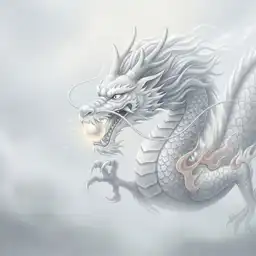
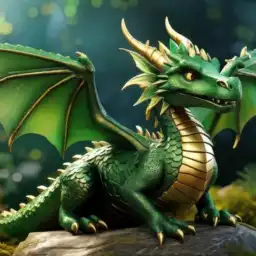


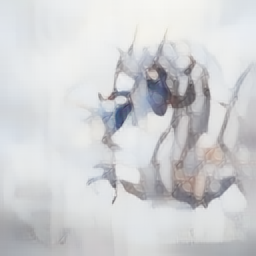
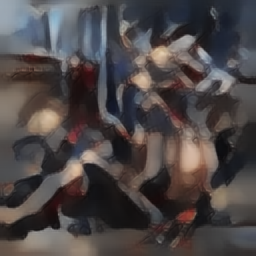

torch.Size([2, 3, 256, 256]) torch.Size([2, 32, 16, 16])



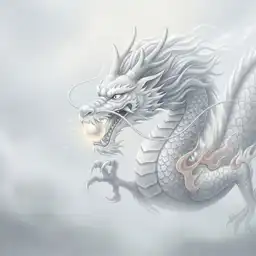
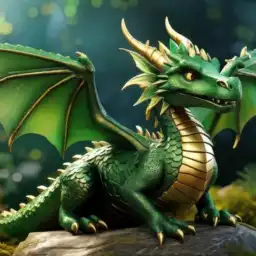


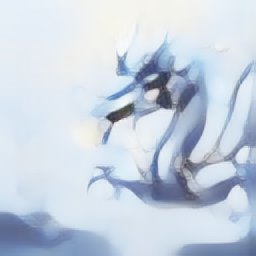
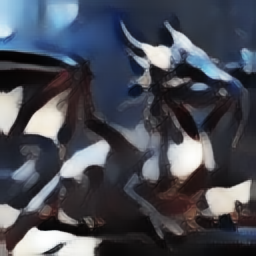

torch.Size([2, 3, 256, 256]) torch.Size([2, 32, 16, 16])



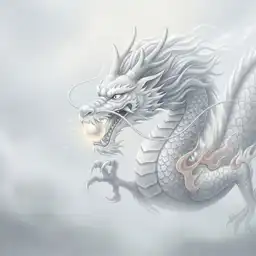
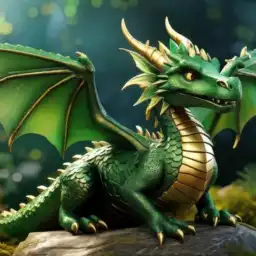


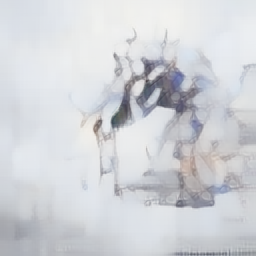
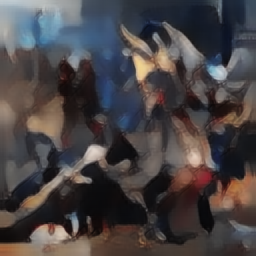

torch.Size([2, 3, 256, 256]) torch.Size([2, 32, 16, 16])



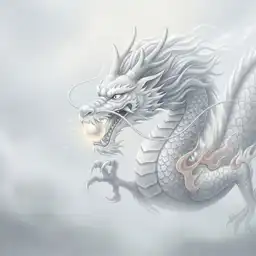
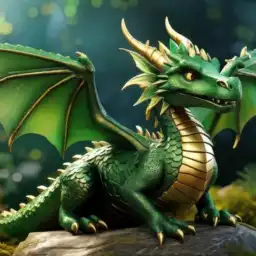


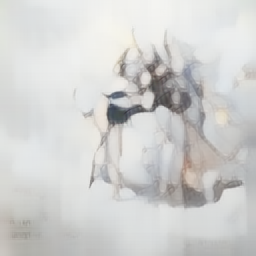
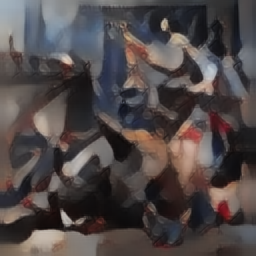

torch.Size([2, 3, 256, 256]) torch.Size([2, 32, 16, 16])



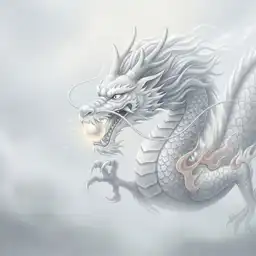
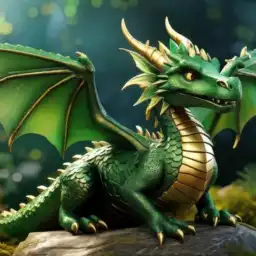


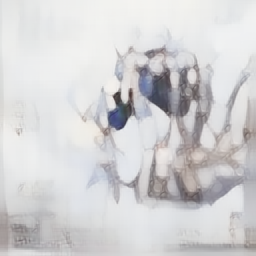
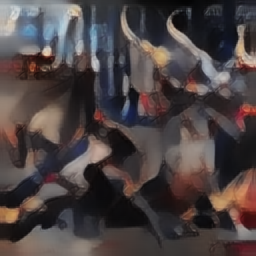

torch.Size([2, 3, 256, 256]) torch.Size([2, 32, 16, 16])



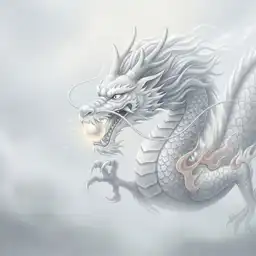
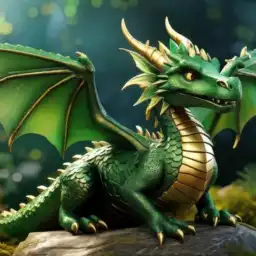


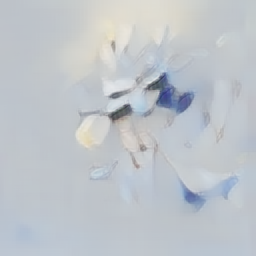
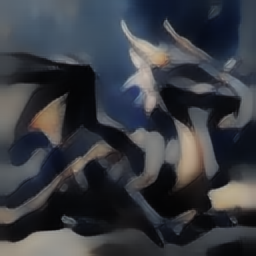

torch.Size([2, 3, 256, 256]) torch.Size([2, 32, 16, 16])



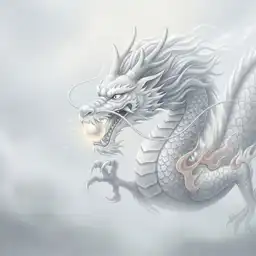
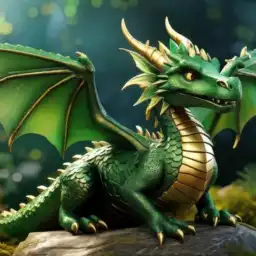


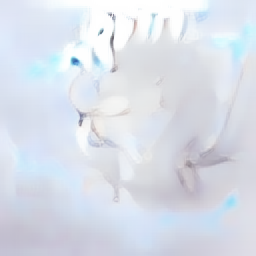
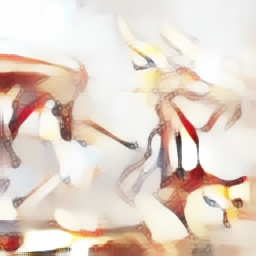

torch.Size([2, 3, 256, 256]) torch.Size([2, 32, 16, 16])



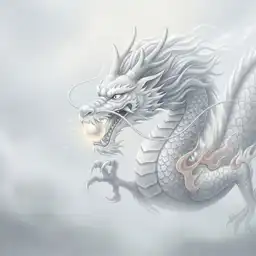
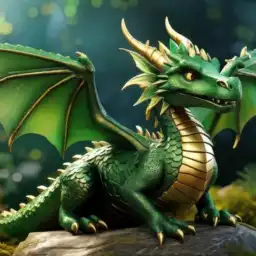


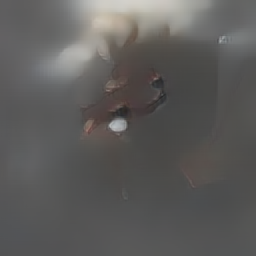
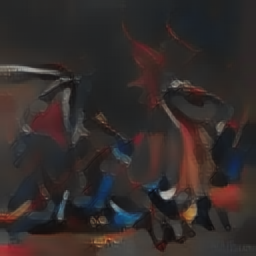

In [41]:
import IPython.display as ipd

imgs = next(iter(train_loader))
for bit_to_flip in range(8):
  with torch.inference_mode():
    reconstructions, aux = autoencoder(imgs)
    o1 = ih.tensor_to_pil(imgs[0])
    o2 = ih.tensor_to_pil(imgs[1])
    print(imgs.shape,aux.latents.shape)
    l1 = aux.latents[0]
    l2 = aux.latents[1]
    z = autoencoder.pre_quant(aux.latents)
    z[:,bit_to_flip]=-z[:,bit_to_flip]
    z = autoencoder.post_quant(z)
    rec = autoencoder.backbone.decode(z)
    ipd.display(ipd.HTML(ih.html_for_images([o1,o2],min_height=256)))
    r1 = ih.tensor_to_pil(rec[0])
    r2 = ih.tensor_to_pil(rec[1])
    ipd.display(ipd.HTML(ih.html_for_images([r1,r2],min_height=256)))



In [ ]:
import IPython.display as ipd

imgs = next(iter(train_loader))
for bit_to_flip in range(8):
  with torch.inference_mode():
    reconstructions, aux = autoencoder(imgs)
    o1 = ih.tensor_to_pil(imgs[0])
    o2 = ih.tensor_to_pil(imgs[1])
    print(imgs.shape,aux.latents.shape)
    l1 = aux.latents[0]
    l2 = aux.latents[1]
    z = autoencoder.pre_quant(aux.latents)
    z[:,bit_to_flip]=-z[:,bit_to_flip]
    z = autoencoder.post_quant(z)
    rec = autoencoder.backbone.decode(z)
    ipd.display(ipd.HTML(ih.html_for_images([o1,o2],min_height=256)))
    r1 = ih.tensor_to_pil(rec[0])
    r2 = ih.tensor_to_pil(rec[1])
    ipd.display(ipd.HTML(ih.html_for_images([r1,r2],min_height=256)))



In [42]:


from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch
from PIL import Image
import numpy as np
import hierarchical_binary_quantization.misc.image_helpers as ih
import IPython.display as ipd

def q_out_to_rgb(q_out):
    B, C, H, W = q_out.shape
    rgb_images = []
    for b in range(B):
        # (C,H,W) -> (H*W,C)
        x = q_out[b].permute(1, 2, 0).reshape(-1, C)
        x = x.detach().cpu().numpy()
        rgb = PCA(n_components=3, whiten=True).fit_transform(x)
        rgb -= rgb.min(axis=0, keepdims=True)
        rgb /= rgb.max(axis=0, keepdims=True) + 1e-8
        rgb = torch.from_numpy(rgb.reshape(H, W, 3)).float()
        rgb_images.append(rgb)
    return torch.stack(rgb_images)

def show_reconstructions(model, imgs):
    was_training = model.training
    model.eval()
    with torch.inference_mode():
        reconstructions, aux = model(imgs[:1])
    if was_training:
        model.train()
    original = ih.tensor_to_pil(imgs[0])
    reconstruction = ih.tensor_to_pil(reconstructions[0])
    latent = ih.tensor_to_pil(q_out_to_rgb(aux.quant_info.quantized)[0])
    print(
        f"latent: μ={aux.latents.mean():.3f}  σ={aux.latents.std():.3f}"
    )
    if aux.quant_info.tokens is not None:
        unique = aux.quant_info.tokens.unique().numel()
        print(
            f"unique tokens={unique} out of "
            f"{2**(aux.quant_info.n_rounds * model.config.quant_dim)}."
        )

    h = ih.html_for_images([original, latent, reconstruction],min_height=128)
    return h, original, latent, reconstruction

# imgs = next(iter(train_loader)).to('cpu')
# h,*i2 = show_reconstructions(autoencoder, imgs)
# ipd.display(ipd.HTML(h))


latent: μ=0.268  σ=1.788
unique tokens=256 out of 281474976710656.



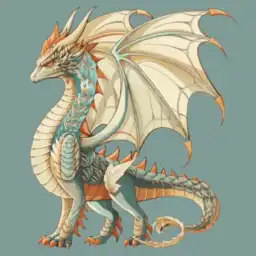
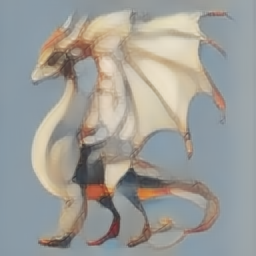

In [56]:
imgs = next(iter(train_loader))
autoencoder.quantizer = hbq.HBQQuantizer(n_rounds=6)
h,*i2 = show_reconstructions(autoencoder, imgs)
ipd.display(ipd.HTML(h))


latent: μ=0.268  σ=1.788
unique tokens=87 out of 256.



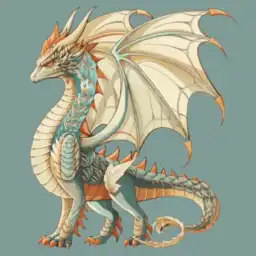
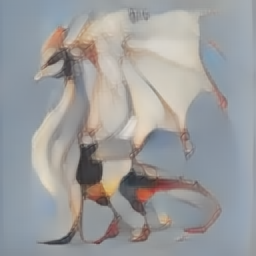

In [57]:
autoencoder.quantizer = hbq.HBQQuantizer(n_rounds=1)
h,*i2 = show_reconstructions(autoencoder, imgs)
ipd.display(ipd.HTML(h))

latent: μ=0.268  σ=1.788
unique tokens=227 out of 65536.



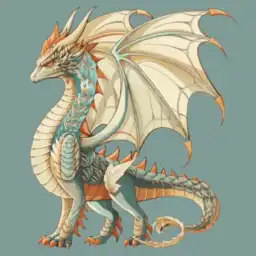
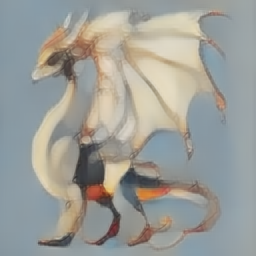

In [58]:
autoencoder.quantizer = hbq.HBQQuantizer(n_rounds=2)
h,*i2 = show_reconstructions(autoencoder, imgs)
ipd.display(ipd.HTML(h))

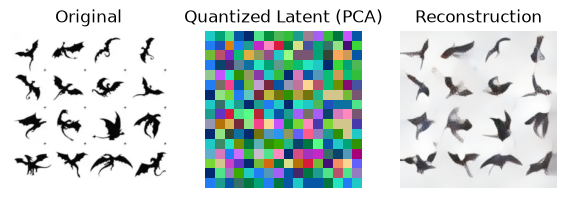

latent: μ=0.196  σ=2.031   
unique tokens=86 out of 256.


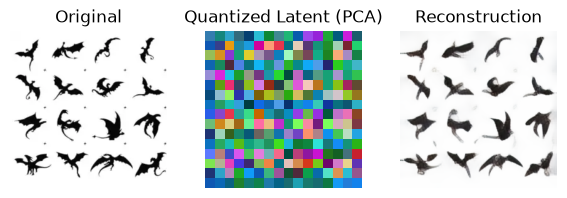

latent: μ=0.196  σ=2.031   
unique tokens=229 out of 65536.


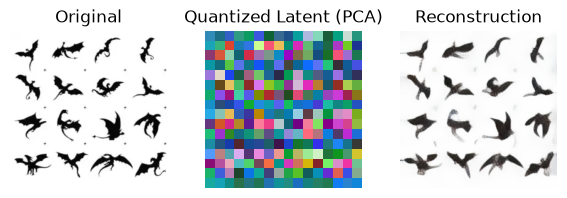

latent: μ=0.196  σ=2.031   
unique tokens=256 out of 16777216.


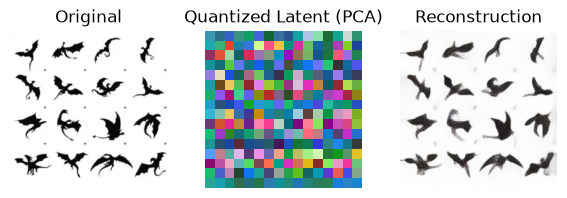

latent: μ=0.196  σ=2.031   


In [9]:
imgs = next(iter(train_loader))
model = autoencoder
def try_quant_level(n_rounds):
    model.eval()
    different_quant = hbq.HBQQuantizer(n_rounds=n_rounds)
    model.quantizer=different_quant
    with torch.inference_mode():
        reconstructions, aux = model(imgs[:1])
    
    latents = aux.latents 
    original = (imgs[0].detach().cpu().permute(1,2,0)/2+0.5).clamp(0,1)
    with torch.inference_mode():
        z1 = model.pre_quant(latents)
        z2 = different_quant(z1)[0]
        #z2 = (torch.tanh(z1)+ torch.rand(1, 4, 32, 32).to(device)-0.5).clamp(-1,1)
        #z2 = z1.clamp(-1,1)
        reconstructions = model.backbone.decode(model.post_quant(z2))
    reconstruction = (reconstructions[0].detach().cpu().permute(1,2,0)/2+0.5).clamp(0,1)
    latent_rgb = q_out_to_rgb(aux.quant_info.quantized)[0]
    
    fig, axes = plt.subplots(1, 3, figsize=(6,2))
    
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis("off")
    
    axes[1].imshow(latent_rgb)
    axes[1].set_title("Quantized Latent (PCA)")
    axes[1].axis("off")
    
    axes[2].imshow(reconstruction)
    axes[2].set_title("Reconstruction")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    # Nice debugging stats
    print(
        f"latent: μ={aux.latents.mean():.3f}  σ={aux.latents.std():.3f}   "
    )
    if aux.quant_info.tokens is not None:
        unique = aux.quant_info.tokens.unique().numel()
        print(
                f"unique tokens={unique} out of {2**(aux.quant_info.n_rounds * model.config.quant_dim)}."
        )
try_quant_level(1)
try_quant_level(2)
try_quant_level(3)
try_quant_level(99)

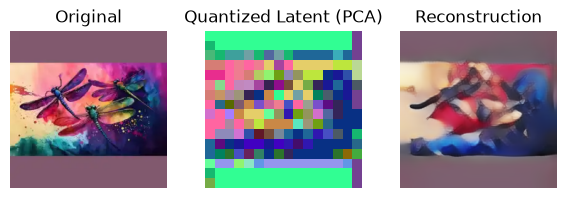

latent: μ=0.226  σ=1.793   
unique tokens=68 out of 256.


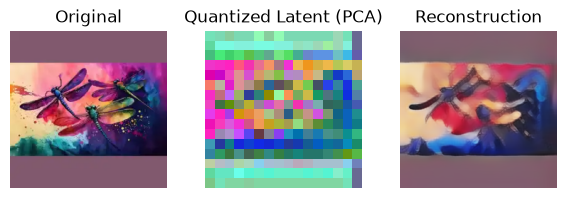

latent: μ=0.226  σ=1.793   
unique tokens=190 out of 65536.


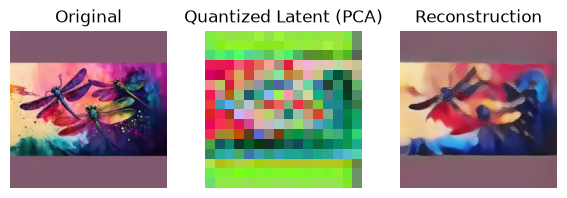

latent: μ=0.226  σ=1.793   
unique tokens=225 out of 16777216.


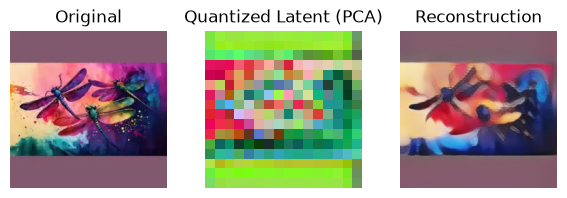

latent: μ=0.226  σ=1.793   


In [59]:
imgs = next(iter(train_loader))
model = autoencoder
def try_quant_level(n_rounds):
    model.eval()
    different_quant = hbq.HBQQuantizer(n_rounds=n_rounds)
    model.quantizer=different_quant
    with torch.inference_mode():
        reconstructions, aux = model(imgs[:1])
    
    latents = aux.latents 
    original = (imgs[0].detach().cpu().permute(1,2,0)/2+0.5).clamp(0,1)
    with torch.inference_mode():
        z1 = model.pre_quant(latents)
        z2 = different_quant(z1)[0]
        #z2 = (torch.tanh(z1)+ torch.rand(1, 4, 32, 32).to(device)-0.5).clamp(-1,1)
        #z2 = z1.clamp(-1,1)
        reconstructions = model.backbone.decode(model.post_quant(z2))
    reconstruction = (reconstructions[0].detach().cpu().permute(1,2,0)/2+0.5).clamp(0,1)
    latent_rgb = q_out_to_rgb(aux.quant_info.quantized)[0]
    
    fig, axes = plt.subplots(1, 3, figsize=(6,2))
    
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis("off")
    
    axes[1].imshow(latent_rgb)
    axes[1].set_title("Quantized Latent (PCA)")
    axes[1].axis("off")
    
    axes[2].imshow(reconstruction)
    axes[2].set_title("Reconstruction")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    # Nice debugging stats
    print(
        f"latent: μ={aux.latents.mean():.3f}  σ={aux.latents.std():.3f}   "
    )
    if aux.quant_info.tokens is not None:
        unique = aux.quant_info.tokens.unique().numel()
        print(
                f"unique tokens={unique} out of {2**(aux.quant_info.n_rounds * model.config.quant_dim)}."
        )
try_quant_level(1)
try_quant_level(2)
try_quant_level(3)
try_quant_level(99)

In [ ]:
imgs = next(iter(train_loader))
model = autoencoder
def try_quant_level(n_rounds):
    model.eval()
    different_quant = hbq.HBQQuantizer(n_rounds=n_rounds)
    model.quantizer=different_quant
    with torch.inference_mode():
        reconstructions, aux = model(imgs[:1])
    
    latents = aux.latents 
    original = (imgs[0].detach().cpu().permute(1,2,0)/2+0.5).clamp(0,1)
    with torch.inference_mode():
        z1 = model.pre_quant(latents)
        z2 = different_quant(z1)[0]
        #z2 = (torch.tanh(z1)+ torch.rand(1, 4, 32, 32).to(device)-0.5).clamp(-1,1)
        #z2 = z1.clamp(-1,1)
        reconstructions = model.backbone.decode(model.post_quant(z2))
    reconstruction = (reconstructions[0].detach().cpu().permute(1,2,0)/2+0.5).clamp(0,1)
    latent_rgb = q_out_to_rgb(aux.quant_info.quantized)[0]
    
    fig, axes = plt.subplots(1, 3, figsize=(6,2))
    
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis("off")
    
    axes[1].imshow(latent_rgb)
    axes[1].set_title("Quantized Latent (PCA)")
    axes[1].axis("off")
    
    axes[2].imshow(reconstruction)
    axes[2].set_title("Reconstruction")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    # Nice debugging stats
    print(
        f"latent: μ={aux.latents.mean():.3f}  σ={aux.latents.std():.3f}   "
    )
    if aux.quant_info.tokens is not None:
        unique = aux.quant_info.tokens.unique().numel()
        print(
                f"unique tokens={unique} out of {2**(aux.quant_info.n_rounds * model.config.quant_dim)}."
        )
try_quant_level(1)
try_quant_level(2)
try_quant_level(3)
try_quant_level(99)